# Fidelity Trajectory Plot: Data Generation & Visualization

## Imports and Setup:

In [1]:
# Mount Drive and set up directories
from google.colab import drive
drive.mount('/content/drive')

import os
BASE_DIR = '/content/drive/MyDrive/GNN_MEA/'
VICTIM_DIR = os.path.join(BASE_DIR, 'victim_models')
EXPLAINER_DIR = os.path.join(BASE_DIR, 'explainers')
RESULTS_DIR = os.path.join(BASE_DIR, 'results')
ARCHITECTURES = ['GCN', 'GAT', 'GraphSAGE']

Mounted at /content/drive


In [2]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.0 MB/s eta 0:00:00


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, GATConv, SAGEConv, global_mean_pool
from torch_geometric.transforms import BaseTransform, OneHotDegree
from sklearn.model_selection import train_test_split
import numpy as np
import copy
import json
from datetime import datetime

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## Dataset Loading:

In [4]:
from torch_geometric.transforms import OneHotDegree

# All datasets
DATASET_NAMES = [
    'MUTAG', 'PTC_FM', 'NCI1', 'Tox21_AhR_training'
]

datasets = {}
for name in DATASET_NAMES:
    ds = TUDataset(root=f'data/{name}', name=name)

    # Fallback: constant features if no features
    if ds[0].x is None or ds[0].x.shape[1] == 0:
        ds = TUDataset(root=f'data/{name}', name=name,
                       transform=AddConstantFeatures())
        print(f"{name}: {len(ds)} graphs, {ds.num_classes} classes, "
              f"added constant features (dim=1)")
    else:
        print(f"{name}: {len(ds)} graphs, {ds.num_classes} classes, "
              f"{ds[0].x.shape[1]} features")

    datasets[name] = ds
    assert ds[0].x is not None, f"{name}: features still None!"
    print(f"  Verified: feature dim = {ds[0].x.shape[1]}")

Processing...
Done!


MUTAG: 188 graphs, 2 classes, 7 features
  Verified: feature dim = 7


Processing...
Done!


PTC_FM: 349 graphs, 2 classes, 18 features
  Verified: feature dim = 18


Processing...
Done!


NCI1: 4110 graphs, 2 classes, 37 features
  Verified: feature dim = 37


Processing...


Tox21_AhR_training: 8169 graphs, 2 classes, 50 features
  Verified: feature dim = 50


Done!


## Data Splits:

In [5]:
# Stratified 60% train / 20% shadow / 20% test split
def split_dataset(dataset, seed=42):
    labels = [data.y.item() for data in dataset]
    train_idx, remaining_idx = train_test_split(
        range(len(dataset)), test_size=0.4,
        stratify=labels, random_state=seed)
    remaining_labels = [labels[i] for i in remaining_idx]
    shadow_idx, test_idx = train_test_split(
        remaining_idx, test_size=0.5,
        stratify=remaining_labels, random_state=seed)
    return train_idx, shadow_idx, test_idx

def get_feature_dim(dataset):
    return dataset[0].x.shape[1]

# Compute splits for all datasets
dataset_splits = {}
for name in DATASET_NAMES:
    dataset_splits[name] = dict(zip(
        ['train', 'shadow', 'test'],
        split_dataset(datasets[name])))

## Model Architectures:

In [6]:
# 3-layer GNN architectures
class GCN(nn.Module):
    def __init__(self, in_dim, hidden_dim, num_classes, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)
        self.classifier = nn.Linear(hidden_dim, num_classes)
        self.dropout = dropout

    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv3(x, edge_index))
        x = global_mean_pool(x, batch)
        x = self.classifier(x)
        return x

class GAT(nn.Module):
    def __init__(self, in_dim, hidden_dim, num_classes, dropout=0.5):
        super().__init__()
        self.conv1 = GATConv(in_dim, hidden_dim // 8, heads=8)
        self.conv2 = GATConv(hidden_dim, hidden_dim // 8, heads=8)
        self.conv3 = GATConv(hidden_dim, hidden_dim // 8, heads=8)
        self.classifier = nn.Linear(hidden_dim, num_classes)
        self.dropout = dropout

    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv3(x, edge_index))
        x = global_mean_pool(x, batch)
        x = self.classifier(x)
        return x

class GraphSAGE(nn.Module):
    def __init__(self, in_dim, hidden_dim, num_classes, dropout=0.5):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)
        self.conv3 = SAGEConv(hidden_dim, hidden_dim)
        self.classifier = nn.Linear(hidden_dim, num_classes)
        self.dropout = dropout

    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv3(x, edge_index))
        x = global_mean_pool(x, batch)
        x = self.classifier(x)
        return x

MODEL_CLASSES = {'GCN': GCN, 'GAT': GAT, 'GraphSAGE': GraphSAGE}

## Load Victim Models:

In [7]:
def load_victim(name, arch, dataset, device='cuda'):
    save_path = os.path.join(VICTIM_DIR, arch, f'{name}_victim.pt')
    checkpoint = torch.load(save_path, map_location=device, weights_only=False)
    ModelClass = MODEL_CLASSES[arch]
    model = ModelClass(
        checkpoint['in_dim'],
        checkpoint['config']['hidden_dim'],
        checkpoint['num_classes']
    ).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    return model, checkpoint

def get_prediction(model, data, device='cuda'):
    model.eval()
    data = data.to(device)
    batch = torch.zeros(data.num_nodes, dtype=torch.long, device=device)
    with torch.no_grad():
        pred = model(data.x, data.edge_index, batch).argmax(dim=1).item()
    return pred

# Load all victim models
victim_models = {}
for name in DATASET_NAMES:
    ds = datasets[name]
    for arch in ARCHITECTURES:
        key = f"{name}_{arch}"
        path = os.path.join(VICTIM_DIR, arch, f'{name}_victim.pt')
        if os.path.exists(path):
            model, ckpt = load_victim(name, arch, ds, device)
            victim_models[key] = model
            print(f"  Loaded {key}: acc={ckpt['accuracy']:.4f}")
        else:
            print(f"  MISSING: {key}")

  Loaded MUTAG_GCN: acc=0.7895
  Loaded MUTAG_GAT: acc=0.7895
  Loaded MUTAG_GraphSAGE: acc=0.7632
  Loaded PTC_FM_GCN: acc=0.6571
  Loaded PTC_FM_GAT: acc=0.6714
  Loaded PTC_FM_GraphSAGE: acc=0.6429
  Loaded NCI1_GCN: acc=0.6727
  Loaded NCI1_GAT: acc=0.6959
  Loaded NCI1_GraphSAGE: acc=0.7360
  Loaded Tox21_AhR_training_GCN: acc=0.8898
  Loaded Tox21_AhR_training_GAT: acc=0.8953
  Loaded Tox21_AhR_training_GraphSAGE: acc=0.8953


## Explainer Setup:

In [8]:
from torch_geometric.explain import (Explainer, PGExplainer, GNNExplainer)

def get_explanation(explainer, model, data, device='cuda'):
    data = data.to(device)
    batch = torch.zeros(data.num_nodes, dtype=torch.long, device=device)
    target = model(data.x, data.edge_index, batch).argmax(dim=1)

    explanation = explainer(data.x, data.edge_index,
                            target=target, batch=batch)

    if hasattr(explanation, 'node_mask') and explanation.node_mask is not None:
        node_mask = explanation.node_mask
        node_importance = node_mask.mean(dim=1) if node_mask.dim() > 1 else node_mask
        threshold = node_importance.median()
        important_nodes = (node_importance > threshold).nonzero(as_tuple=True)[0]
        src, dst = data.edge_index
        edge_mask_bool = (torch.isin(src, important_nodes) &
                          torch.isin(dst, important_nodes))
        important_edges = edge_mask_bool.nonzero(as_tuple=True)[0]
        return important_nodes.cpu(), important_edges.cpu(), node_importance.cpu()

    elif hasattr(explanation, 'edge_mask') and explanation.edge_mask is not None:
        edge_mask = explanation.edge_mask
        threshold = edge_mask.median()
        important_edges = (edge_mask > threshold).nonzero(as_tuple=True)[0]
        important_nodes = torch.unique(
            data.edge_index[:, important_edges].flatten())
        return important_nodes.cpu(), important_edges.cpu(), edge_mask.cpu()

    else:
        raise ValueError("No mask found in explanation")

def load_pg_explainer(model, name, arch, device='cuda'):
    pg_path = os.path.join(EXPLAINER_DIR, 'PGExplainer', arch,
                            f'{name}_explainer.pt')
    if not os.path.exists(pg_path):
        print(f"  WARNING: No PGExplainer for {arch}/{name}")
        return None

    explainer = Explainer(
        model=model,
        algorithm=PGExplainer(epochs=100, lr=0.003),
        explanation_type='phenomenon',
        edge_mask_type='object',
        model_config=dict(
            mode='multiclass_classification',
            task_level='graph',
            return_type='raw',
        ),
    )
    explainer.algorithm = explainer.algorithm.to(device)
    explainer.algorithm.load_state_dict(
        torch.load(pg_path, weights_only=False))
    explainer.algorithm._curr_epoch = 99
    return explainer

def create_gnn_explainer(model):
    model_copy = copy.deepcopy(model)
    for param in model_copy.parameters():
        param.requires_grad_(True)
    return Explainer(
        model=model_copy,
        algorithm=GNNExplainer(epochs=100, lr=0.01),
        explanation_type='phenomenon',
        node_mask_type='object',
        edge_mask_type=None,
        model_config=dict(
            mode='multiclass_classification',
            task_level='graph',
            return_type='raw',
        ),
    )

## Methods Helper Functions:

In [9]:
# Edge manipulation utilities
def get_edge_set(edge_index):
    edges = set()
    for k in range(edge_index.shape[1]):
        u, v = edge_index[0, k].item(), edge_index[1, k].item()
        edges.add((min(u, v), max(u, v)))
    return edges

def flip_edge_in_list(edge_list, existing, u, v):
    if (u, v) in existing:
        edge_list = [e for e in edge_list
                     if not ((e[0] == u and e[1] == v) or
                             (e[0] == v and e[1] == u))]
        existing.discard((u, v))
    else:
        edge_list.append([u, v])
        edge_list.append([v, u])
        existing.add((u, v))
    return edge_list, existing

## Phase 1: Exhaustive Boundary Detection:

In [10]:
def find_boundary_pairs_exhaustive(dataset, shadow_idx, model, device='cuda'):
    boundary_pairs = []
    non_boundary_idx = []

    for i in shadow_idx:
        data = dataset[i]
        orig_pred = get_prediction(model, data, device)
        existing = get_edge_set(data.edge_index)

        found = False
        for (u, v) in existing:
            flipped = data.clone()
            edge_list = flipped.edge_index.t().tolist()
            edge_list = [e for e in edge_list
                         if not ((e[0] == u and e[1] == v) or
                                 (e[0] == v and e[1] == u))]
            if len(edge_list) == 0:
                continue
            flipped.edge_index = torch.tensor(edge_list, dtype=torch.long).t()
            new_pred = get_prediction(model, flipped, device)

            if new_pred != orig_pred:
                orig = data.clone()
                orig.y = torch.tensor([orig_pred])
                flipped.y = torch.tensor([new_pred])
                boundary_pairs.append((orig, flipped))
                found = True
                break

        if not found:
            non_boundary_idx.append(i)

    print(f"  Phase 1: {len(boundary_pairs)} boundary pairs, "
          f"{len(non_boundary_idx)} non-boundary graphs")
    return boundary_pairs, non_boundary_idx

## Phase 2: Explanation-Guided MC Boundary Search:

In [11]:
def build_candidates(data, important_nodes, carry_over=None, n_random=10):
    n = data.num_nodes
    imp_set = set(important_nodes.tolist())

    neighbors = set()
    for k in range(data.edge_index.shape[1]):
        u, v = data.edge_index[0, k].item(), data.edge_index[1, k].item()
        if u in imp_set and v not in imp_set:
            neighbors.add(v)
        if v in imp_set and u not in imp_set:
            neighbors.add(u)

    candidates = set()
    for u in imp_set:
        for v in imp_set:
            if u < v:
                candidates.add((u, v))
    for u in imp_set:
        for v in neighbors:
            candidates.add((min(u, v), max(u, v)))
    if carry_over is not None:
        candidates.update(carry_over)
    for _ in range(n_random):
        u, v = np.random.randint(0, n, size=2)
        if u != v:
            candidates.add((min(u, v), max(u, v)))

    return candidates

def estimate_edge_sensitivity(data, edge, model, orig_pred,
                              n_samples=5, p_flip=0.05, device='cuda'):
    u, v = edge
    scores = []
    edge_list_orig = data.edge_index.t().tolist()
    existing_orig = get_edge_set(data.edge_index)

    for _ in range(n_samples):
        perturbed_edges = list(edge_list_orig)
        perturbed_existing = set(existing_orig)

        for k in range(data.num_nodes):
            for l in range(k + 1, data.num_nodes):
                if (k, l) == (u, v):
                    continue
                if np.random.random() < p_flip:
                    perturbed_edges, perturbed_existing = flip_edge_in_list(
                        perturbed_edges, perturbed_existing, k, l)

        if len(perturbed_edges) == 0:
            continue

        base = data.clone()
        base.edge_index = torch.tensor(perturbed_edges, dtype=torch.long).t()
        pred_base = get_prediction(model, base, device)

        flipped_edges = list(perturbed_edges)
        flipped_existing = set(perturbed_existing)
        flipped_edges, flipped_existing = flip_edge_in_list(
            flipped_edges, flipped_existing, u, v)

        if len(flipped_edges) == 0:
            continue

        flipped = data.clone()
        flipped.edge_index = torch.tensor(flipped_edges, dtype=torch.long).t()
        pred_flipped = get_prediction(model, flipped, device)

        z = int(pred_flipped != orig_pred) - int(pred_base != orig_pred)
        scores.append(z)

    return np.mean(scores) if scores else 0.0

def boundary_search(data, model, explainer, max_iters=10, top_k=3,
                    n_mc=5, delta_max=20, p_flip=0.05, n_random=10,
                    device='cuda'):
    orig_pred = get_prediction(model, data, device)
    current = data.clone()
    orig_edges = get_edge_set(data.edge_index)
    carry_over = None

    for t in range(max_iters):
        cur_pred = get_prediction(model, current, device)
        cur_edges = get_edge_set(current.edge_index)
        delta_e = len(orig_edges.symmetric_difference(cur_edges))

        if cur_pred != orig_pred and delta_e <= delta_max:
            current.y = torch.tensor([cur_pred])
            return current, delta_e

        if delta_e >= delta_max:
            break

        imp_nodes, imp_edges, mask = get_explanation(
            explainer, model, current, device)
        candidates = build_candidates(current, imp_nodes, carry_over, n_random)

        sensitivities = {}
        for edge in candidates:
            g_hat = estimate_edge_sensitivity(
                current, edge, model, orig_pred, n_mc, p_flip, device)
            sensitivities[edge] = g_hat

        sorted_edges = sorted(sensitivities.items(), key=lambda x: -x[1])
        top_edges = [e for e, s in sorted_edges[:top_k] if s > 0]

        if len(top_edges) == 0:
            break

        edge_list = current.edge_index.t().tolist()
        existing = get_edge_set(current.edge_index)
        for (u, v) in top_edges:
            edge_list, existing = flip_edge_in_list(edge_list, existing, u, v)

        if len(edge_list) > 0:
            current.edge_index = torch.tensor(edge_list, dtype=torch.long).t()

        carry_over = set(e for e, s in sorted_edges[:5] if s > 0)

    return None, 0

def find_boundary_pairs_mc(dataset, remaining_idx, model, explainer,
                           n_needed, device='cuda'):
    boundary_pairs = []
    n_searched = 0

    for i in remaining_idx:
        if len(boundary_pairs) >= n_needed:
            break
        data = dataset[i]
        orig_pred = get_prediction(model, data, device)
        n_searched += 1
        result, d_e = boundary_search(data, model, explainer, device=device)
        if result is not None:
            orig = data.clone()
            orig.y = torch.tensor([orig_pred])
            boundary_pairs.append((orig, result))

    print(f"  Phase 2: {len(boundary_pairs)} additional pairs "
          f"from {n_searched} graphs searched")
    return boundary_pairs

## Methods (Random, Non-Boundary, EGSteal-BB, Boundary, Hybrid):

In [12]:
def method_random(dataset, shadow_idx, model, n_samples, device='cuda'):
    idx = np.random.choice(shadow_idx, min(n_samples, len(shadow_idx)), replace=False)
    train_data = []
    for i in idx:
        data = dataset[i].clone()
        data.y = torch.tensor([get_prediction(model, data, device)])
        train_data.append(data)
    return train_data

def method_non_boundary(dataset, non_boundary_idx, model, n_samples, device='cuda'):
    idx = non_boundary_idx[:n_samples]
    train_data = []
    for i in idx:
        data = dataset[i].clone()
        data.y = torch.tensor([get_prediction(model, data, device)])
        train_data.append(data)
    print(f"  Selected {len(train_data)} non-boundary samples "
          f"(from {len(non_boundary_idx)} available)")
    return train_data

def method_egsteal_bb(dataset, shadow_idx, model, explainer, n_samples,
                      n_perturbations=2, p_flip=0.1, device='cuda'):
    train_data = []
    for i in shadow_idx:
        if len(train_data) >= n_samples:
            break
        data = dataset[i]
        orig_pred = get_prediction(model, data, device)
        orig = data.clone()
        orig.y = torch.tensor([orig_pred])
        train_data.append(orig)

        imp_nodes, imp_edges, mask = get_explanation(explainer, model, data, device)
        imp_node_set = set(imp_nodes.tolist())

        existing = set()
        outside_edges = []
        for k in range(data.edge_index.shape[1]):
            u, v = data.edge_index[0, k].item(), data.edge_index[1, k].item()
            if (min(u, v), max(u, v)) not in existing:
                existing.add((min(u, v), max(u, v)))
                if u not in imp_node_set and v not in imp_node_set:
                    outside_edges.append((u, v))

        for _ in range(n_perturbations):
            perturbed = data.clone()
            edge_list = perturbed.edge_index.t().tolist()
            for (u, v) in outside_edges:
                if np.random.random() < p_flip:
                    edge_list = [e for e in edge_list
                                 if not ((e[0] == u and e[1] == v) or
                                         (e[0] == v and e[1] == u))]
            if len(edge_list) == 0:
                continue
            perturbed.edge_index = torch.tensor(edge_list, dtype=torch.long).t()
            perturbed.y = torch.tensor([orig_pred])
            train_data.append(perturbed)

    print(f"  Generated {len(train_data)} samples")
    return train_data[:n_samples]

def method_boundary(dataset, shadow_idx, model, explainer, n_samples,
                    boundary_pairs_p1=None, non_boundary_idx=None,
                    device='cuda'):
    if boundary_pairs_p1 is None:
        boundary_pairs_p1, non_boundary_idx = find_boundary_pairs_exhaustive(
            dataset, shadow_idx, model, device)

    train_data = []
    for orig, flipped in boundary_pairs_p1:
        train_data.append(orig)
        train_data.append(flipped)

    if len(train_data) < n_samples and non_boundary_idx and len(non_boundary_idx) > 0:
        n_needed = (n_samples - len(train_data)) // 2
        pairs_p2 = find_boundary_pairs_mc(
            dataset, non_boundary_idx, model, explainer, n_needed, device)
        for orig, flipped in pairs_p2:
            train_data.append(orig)
            train_data.append(flipped)

    # Diagnostic
    n_check = min(10, len(train_data) - 1)
    n_mismatch = 0
    for i in range(0, n_check, 2):
        orig_check = get_prediction(model, train_data[i], device)
        flip_check = get_prediction(model, train_data[i+1], device)
        if orig_check != train_data[i].y.item() or flip_check != train_data[i+1].y.item():
            n_mismatch += 1
    if n_mismatch > 0:
        print(f"    WARNING: {n_mismatch}/{n_check//2} pairs have wrong labels!")
    else:
        print(f"    Labels verified: {n_check//2} pairs all correct")

    labels = [d.y.item() for d in train_data[:n_samples]]
    unique, counts = np.unique(labels, return_counts=True)
    print(f"  Training label dist: {dict(zip(unique, counts))}")
    print(f"  Boundary total: {len(train_data[:n_samples])} samples")
    return train_data[:n_samples]

def method_hybrid(dataset, shadow_idx, model, explainer, n_samples,
                  boundary_pairs_p1=None, non_boundary_idx=None,
                  device='cuda'):
    half = n_samples // 2
    boundary_data = method_boundary(
        dataset, shadow_idx, model, explainer, half,
        boundary_pairs_p1, non_boundary_idx, device)
    random_data = method_random(dataset, shadow_idx, model, half, device)
    combined = boundary_data + random_data
    return combined[:n_samples]

## Training and Evaluation:

In [13]:
def train_surrogate(train_data, in_dim, num_classes, arch='GCN', device='cuda'):
    ModelClass = MODEL_CLASSES[arch]
    model = ModelClass(in_dim, 64, num_classes, dropout=0.0).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.CrossEntropyLoss()

    clean_data = []
    for d in train_data:
        d = d.cpu()
        d.y = d.y.long()
        clean_data.append(d)

    loader = DataLoader(clean_data, batch_size=8, shuffle=True)

    model.train()
    for epoch in range(500):
        for batch in loader:
            batch = batch.to(device)
            pred = model(batch.x, batch.edge_index, batch.batch)
            loss = loss_fn(pred, batch.y)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

    model.eval()
    preds = []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            pred = model(batch.x, batch.edge_index, batch.batch)
            preds.extend(pred.argmax(1).cpu().tolist())
    unique, counts = np.unique(preds, return_counts=True)
    print(f"    Surrogate predictions: {dict(zip(unique, counts))}")
    return model

def get_balanced_test_idx(victim, dataset, test_idx, device='cuda', seed=42):
    by_class = {}
    victim.eval()
    with torch.no_grad():
        for idx in test_idx:
            data = dataset[idx].to(device)
            batch = torch.zeros(data.num_nodes, dtype=torch.long, device=device)
            pred = victim(data.x, data.edge_index, batch).argmax(1).item()
            by_class.setdefault(pred, []).append(idx)

    min_count = min(len(v) for v in by_class.values())
    rng = np.random.RandomState(seed)
    balanced_idx = []
    for cls in sorted(by_class.keys()):
        chosen = rng.choice(by_class[cls], min_count, replace=False)
        balanced_idx.extend(chosen)
    return balanced_idx

def evaluate(surrogate, victim, dataset, balanced_idx, device='cuda'):
    surrogate.eval()
    victim.eval()
    correct_fidelity = 0
    correct_accuracy = 0
    total = 0

    with torch.no_grad():
        for idx in balanced_idx:
            data = dataset[idx].to(device)
            batch = torch.zeros(data.num_nodes, dtype=torch.long, device=device)
            surr_pred = surrogate(data.x, data.edge_index, batch).argmax(1).item()
            vic_pred = victim(data.x, data.edge_index, batch).argmax(1).item()
            true_label = data.y.item()
            if surr_pred == vic_pred:
                correct_fidelity += 1
            if surr_pred == true_label:
                correct_accuracy += 1
            total += 1

    return round(correct_fidelity / total, 4), round(correct_accuracy / total, 4)

## Results Manager:

In [14]:
RESULTS_FILE = os.path.join(RESULTS_DIR, 'experiment_results_for_plots.json')

def load_results():
    if os.path.exists(RESULTS_FILE):
        with open(RESULTS_FILE, 'r') as f:
            return json.load(f)
    return {}

def save_result(results, key, value):
    results[key] = value
    with open(RESULTS_FILE, 'w') as f:
        json.dump(results, f, indent=2)

## Experiment Runner (Phase 1 + Phase 2):

In [15]:
def run_experiment(config):
    results = load_results()

    for name in config['datasets']:
        ds = datasets[name]
        splits = dataset_splits[name]
        shadow_idx = splits['shadow']
        test_idx = splits['test']
        in_dim = get_feature_dim(ds)
        num_classes = ds.num_classes

        for arch in config['architectures']:
            key_prefix = f"{name}_{arch}"
            if key_prefix not in victim_models:
                print(f"  SKIP: {key_prefix} not loaded")
                continue

            victim = victim_models[key_prefix]

            balanced_test = get_balanced_test_idx(victim, ds, test_idx, device)
            bal_preds = [get_prediction(victim, ds[idx], device) for idx in balanced_test]
            unique, counts = np.unique(bal_preds, return_counts=True)
            print(f"\n  Balanced test: {len(balanced_test)} samples, "
                  f"victim pred dist: {dict(zip(unique, counts))}")

            print(f"\n{'='*60}")
            print(f"Phase 1: {arch} on {name}")
            print(f"{'='*60}")
            pairs_p1, non_bd_idx = find_boundary_pairs_exhaustive(
                ds, shadow_idx, victim, device)

            for budget in config['budgets']:
                n_samples = int(len(shadow_idx) * budget)
                budget_str = f"{int(budget*100)}pct"

                for method in config['methods']:
                    if method in ['Random', 'Non-boundary']:
                        exp_configs = [(None, 'none')]
                    else:
                        exp_configs = []
                        for exp_name in config['explainers']:
                            if exp_name == 'PG':
                                exp = load_pg_explainer(victim, name, arch, device)
                            elif exp_name == 'GNN':
                                exp = create_gnn_explainer(victim)
                            else:
                                continue
                            if exp is not None:
                                exp_configs.append((exp, exp_name))

                    for explainer, exp_name in exp_configs:
                        result_key = f"{name}_{arch}_{method}_{exp_name}_{budget_str}"

                        if result_key in results:
                            print(f"  SKIP (cached): {result_key}")
                            continue

                        print(f"\n--- {result_key} ---")

                        try:
                            if method == 'Random':
                                train_data = method_random(
                                    ds, shadow_idx, victim, n_samples, device)
                            elif method == 'Non-boundary':
                                train_data = method_non_boundary(
                                    ds, non_bd_idx, victim, n_samples, device)
                            elif method == 'EGSteal-BB':
                                train_data = method_egsteal_bb(
                                    ds, shadow_idx, victim, explainer,
                                    n_samples, device=device)
                            elif method == 'Boundary':
                                train_data = method_boundary(
                                    ds, shadow_idx, victim, explainer,
                                    n_samples, pairs_p1, non_bd_idx, device)
                            elif method == 'Hybrid':
                                train_data = method_hybrid(
                                    ds, shadow_idx, victim, explainer,
                                    n_samples, pairs_p1, non_bd_idx, device)
                        except Exception as e:
                            print(f"  ERROR: {e}")
                            continue

                        if len(train_data) == 0:
                            print(f"  No training data, skipping")
                            continue

                        print(f"  Training surrogate ({len(train_data)} samples)...")
                        surrogate = train_surrogate(
                            train_data, in_dim, num_classes, arch, device)

                        fid, acc = evaluate(
                            surrogate, victim, ds, balanced_test, device)

                        result = {
                            'fidelity': fid,
                            'accuracy': acc,
                            'n_train': len(train_data),
                            'timestamp': datetime.now().isoformat(),
                        }

                        print(f"  Fidelity: {fid:.4f}, Accuracy: {acc:.4f}")
                        save_result(results, result_key, result)

    print(f"\nAll results saved to {RESULTS_FILE}")
    return results

## Run Experiments:

Runs all datasets × architectures × methods at 5% budget increments.
Skips any experiment already cached in the JSON.

In [ ]:
results = run_experiment({
    'datasets': ['MUTAG', 'PTC_FM', 'NCI1', 'Tox21_AhR_training'],
    'architectures': ['GCN', 'GAT', 'GraphSAGE'],
    'explainers': ['GNN', 'PG'],
    'methods': ['Random', 'Non-boundary', 'EGSteal-BB', 'Boundary', 'Hybrid'],
    'budgets': [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40,
                0.45, 0.50, 0.55, 0.60, 0.65, 0.70],
})

## Fidelity Trajectory Plot (PDF):

In [16]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.size'] = 12
matplotlib.rcParams['mathtext.fontset'] = 'cm'

# ============================================================
# CONFIGURATION
# ============================================================
RESULTS_PATH = RESULTS_FILE

METHODS_TO_PLOT = [
    'Boundary',
    'Hybrid',
    'Random',
    'EGSteal-BB',
    'Non-boundary',
]

PLOT_ARCHITECTURES = ['GCN', 'GAT', 'GraphSAGE']
PLOT_DATASETS = ['MUTAG', 'PTC_FM', 'NCI1', 'Tox21_AhR_training']

MONOTONE_ENVELOPE = True
SMOOTHING_WINDOW = 3    # Set to 1 to disable smoothing

SHOW_INLINE = True
SAVE_PDF = True
SAVE_COMBINED = True
# ============================================================

with open(RESULTS_PATH, 'r') as f:
    plot_results = json.load(f)

ds_display = {
    'MUTAG': 'MUTAG', 'PTC_FM': 'PTC_FM',
    'NCI1': 'NCI1', 'Tox21_AhR_training': 'Tox21',
}

budgets = list(range(5, 75, 5))

method_styles = {
    'Boundary':      {'color': '#2ca02c', 'lw': 2.8, 'ls': '-',  'label': 'Boundary (Ours)'},
    'Hybrid':        {'color': '#1f77b4', 'lw': 2.8, 'ls': '-',  'label': 'Hybrid (Ours)'},
    'Random':        {'color': '#ff7f0e', 'lw': 1.5, 'ls': '--', 'label': 'Random'},
    'EGSteal-BB':    {'color': '#d62728', 'lw': 1.5, 'ls': '-.', 'label': 'EGSteal-BB'},
    'Non-boundary':  {'color': '#9467bd', 'lw': 1.5, 'ls': ':',  'label': 'Non-boundary'},
}

def get_key(ds, arch, method, budget, exp_code):
    exp = 'none' if method in ['Random', 'Non-boundary'] else exp_code
    return f'{ds}_{arch}_{method}_{exp}_{budget}pct'

def get_trajectory_raw(ds, arch, method, exp_code):
    """Extract all (n_train, fidelity) pairs sorted by n_train."""
    xs, ys = [], []
    for b in budgets:
        k = get_key(ds, arch, method, b, exp_code)
        if k in plot_results:
            xs.append(plot_results[k]['n_train'])
            ys.append(plot_results[k]['fidelity'] * 100)
    if not xs:
        return [], []
    paired = sorted(zip(xs, ys))
    return [p[0] for p in paired], [p[1] for p in paired]

def get_ntrain_cap(ds, arch, exp_code):
    """Find the smallest max n_train across all methods."""
    max_ntrains = []
    for method in METHODS_TO_PLOT:
        xs, _ = get_trajectory_raw(ds, arch, method, exp_code)
        if xs:
            max_ntrains.append(max(xs))
    return min(max_ntrains) if max_ntrains else 0

def get_ntrain_floor(ds, arch, exp_code):
    """Find the largest min n_train across all methods."""
    min_ntrains = []
    for method in METHODS_TO_PLOT:
        xs, _ = get_trajectory_raw(ds, arch, method, exp_code)
        if xs:
            min_ntrains.append(min(xs))
    return max(min_ntrains) if min_ntrains else 0

def apply_processing(xs, ys):
    """Apply monotone envelope + smoothing."""
    if not ys:
        return xs, ys

    if MONOTONE_ENVELOPE:
        for i in range(1, len(ys)):
            ys[i] = max(ys[i], ys[i-1])

    if SMOOTHING_WINDOW > 1 and len(ys) >= SMOOTHING_WINDOW:
        ys_arr = np.array(ys, dtype=float)
        kernel = np.ones(SMOOTHING_WINDOW) / SMOOTHING_WINDOW
        smoothed = np.convolve(ys_arr, kernel, mode='valid')
        pad_left = (SMOOTHING_WINDOW - 1) // 2
        pad_right = SMOOTHING_WINDOW - 1 - pad_left
        ys_smooth = list(ys[:pad_left]) + list(smoothed) + (list(ys[-pad_right:]) if pad_right > 0 else [])
        if MONOTONE_ENVELOPE:
            for i in range(1, len(ys_smooth)):
                ys_smooth[i] = max(ys_smooth[i], ys_smooth[i-1])
        ys = ys_smooth

    return xs, ys

def plot_panel(ax, ds, arch, exp_code, add_legend=False):
    """Plot one subplot panel."""
    ntrain_cap = get_ntrain_cap(ds, arch, exp_code)
    ntrain_floor = get_ntrain_floor(ds, arch, exp_code)

    for method in METHODS_TO_PLOT:
        s = method_styles[method]
        xs, ys = get_trajectory_raw(ds, arch, method, exp_code)
        if not xs:
            continue
        xs, ys = apply_processing(xs, ys)
        ax.plot(xs, ys, color=s['color'], linewidth=s['lw'], linestyle=s['ls'],
                label=s['label'] if add_legend else None)

    ax.set_xlim(left=ntrain_floor, right=ntrain_cap)
    ax.grid(True, alpha=0.25, linewidth=0.5)
    ax.tick_params(labelsize=7)

def make_single_figure(arch, exp_code='GNN', filename=None, show=True, save=True):
    n_ds = len(PLOT_DATASETS)
    fig, axes = plt.subplots(1, n_ds, figsize=(5 * n_ds, 3.5))
    if n_ds == 1: axes = [axes]

    for i, ds in enumerate(PLOT_DATASETS):
        plot_panel(axes[i], ds, arch, exp_code, add_legend=(i == 0))
        axes[i].set_title(f'{ds_display[ds]}', fontsize=10, fontweight='bold')
        if i == 0:
            axes[i].set_ylabel('Fidelity (%)', fontsize=10)
        axes[i].set_xlabel('$n_{\\mathrm{train}}$', fontsize=10)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=len(METHODS_TO_PLOT),
               fontsize=9, bbox_to_anchor=(0.5, 1.02), frameon=True,
               fancybox=True, edgecolor='#cccccc', facecolor='white')
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    if save and filename:
        plt.savefig(filename, dpi=200, bbox_inches='tight')
        print(f"Saved {filename}")
    if show: plt.show()
    else: plt.close()

def make_combined_figure(filename=None, show=True, save=True):
    explainers = ['GNN', 'PG']
    n_rows = len(PLOT_DATASETS)
    n_cols = len(PLOT_ARCHITECTURES) * len(explainers)  # 6 columns
    fig, all_axes = plt.subplots(n_rows, n_cols, figsize=(2.8 * n_cols, 2.5 * n_rows))

    for row, ds in enumerate(PLOT_DATASETS):
        for exp_idx, exp_code in enumerate(explainers):
            for arch_idx, arch in enumerate(PLOT_ARCHITECTURES):
                col = exp_idx * len(PLOT_ARCHITECTURES) + arch_idx
                ax = all_axes[row, col]
                plot_panel(ax, ds, arch, exp_code,
                           add_legend=(row == 0 and col == 0))

                # Titles only on first row
                if row == 0:
                    ax.set_title(f'{arch}', fontsize=9, fontweight='bold')
                else:
                    ax.set_title('')

                # y-label only on leftmost of each explainer group
                if arch_idx == 0:
                    ax.set_ylabel('Fidelity (%)', fontsize=9)
                else:
                    ax.set_ylabel('')

                # x-label only on bottom row
                if row == n_rows - 1:
                    ax.set_xlabel('$n_{\\mathrm{train}}$', fontsize=9)

                # Dataset label on left margin
                if col == 0:
                    ax.annotate(ds_display[ds], xy=(-0.45, 0.5),
                                xycoords='axes fraction', fontsize=10,
                                fontweight='bold', rotation=90,
                                ha='center', va='center')

    # Explainer group titles
    fig.text(0.28, 1.01, 'GNNExplainer', ha='center', fontsize=12, fontweight='bold')
    fig.text(0.75, 1.01, 'PGExplainer', ha='center', fontsize=12, fontweight='bold')

    handles, labels = all_axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=len(METHODS_TO_PLOT),
               fontsize=9, bbox_to_anchor=(0.5, -0.02), frameon=True,
               fancybox=True, edgecolor='#cccccc', facecolor='white')
    plt.tight_layout(rect=[0.03, 0.03, 1, 1.0])
    if save and filename:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"Saved {filename}")
    if show: plt.show()
    else: plt.close()

## Generate Plots:

Saved fidelity_ntrain_GCN_GNN.pdf


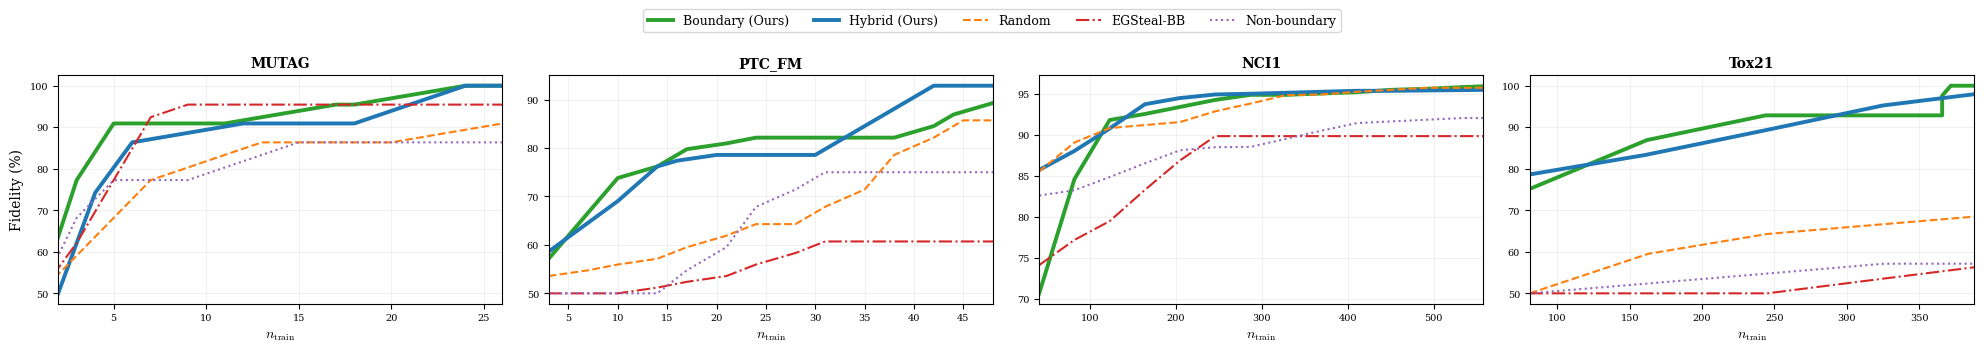

Saved fidelity_ntrain_GAT_GNN.pdf


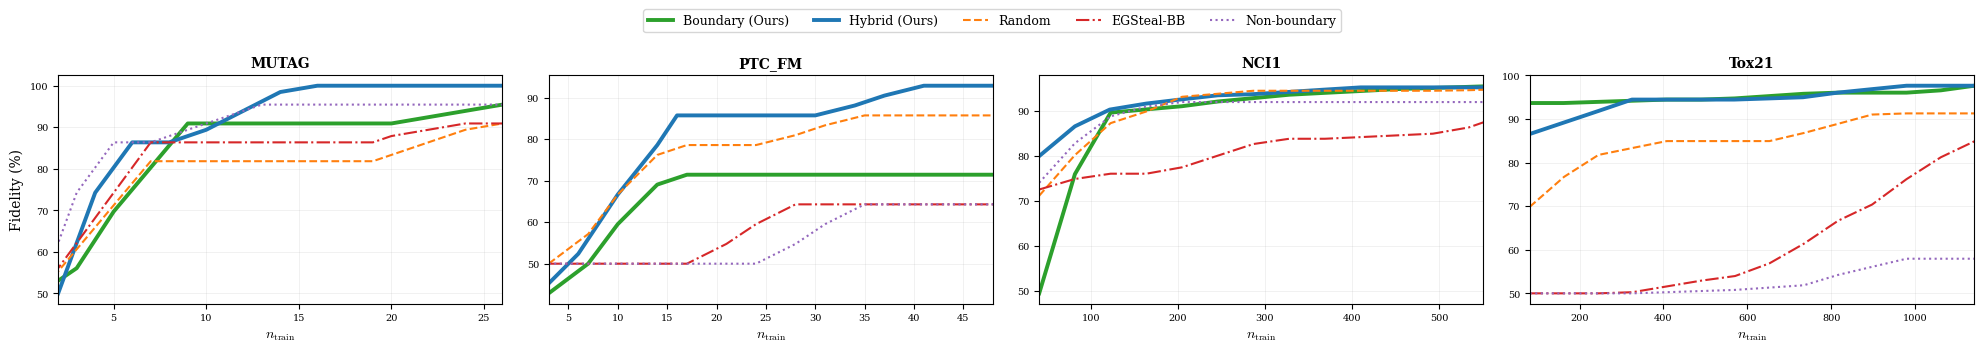

Saved fidelity_ntrain_GraphSAGE_GNN.pdf


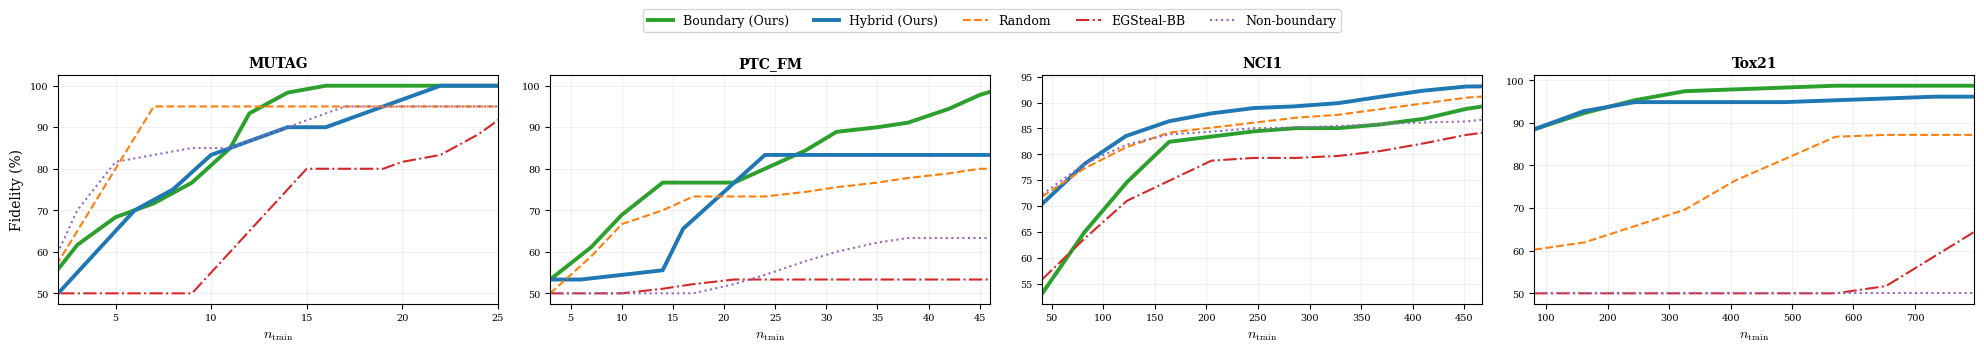

Saved fidelity_ntrain_GCN_PG.pdf


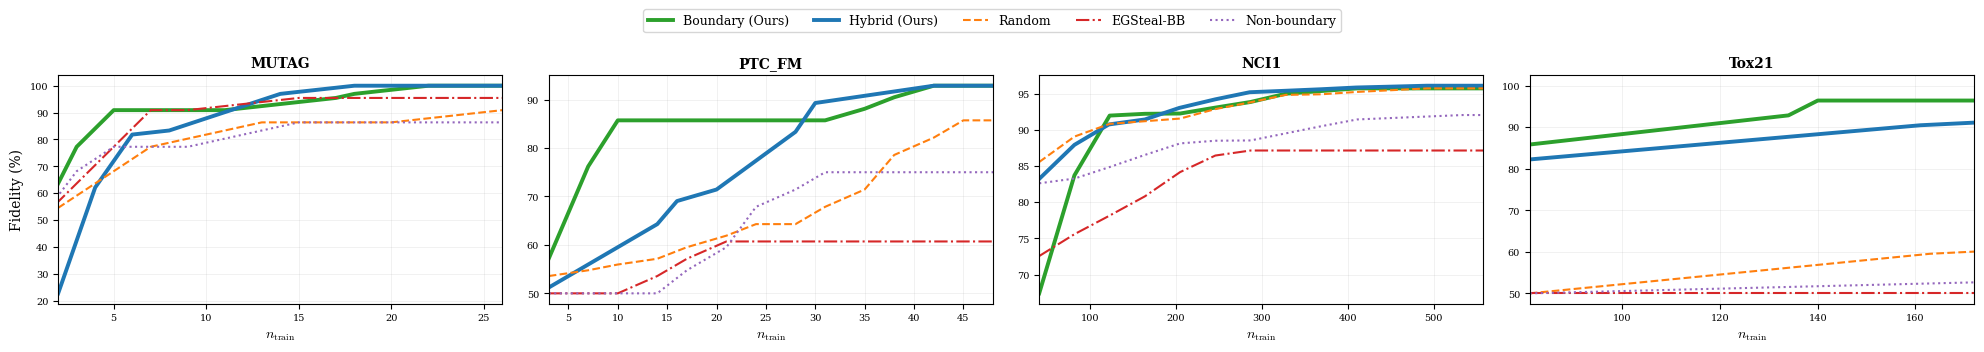

Saved fidelity_ntrain_GAT_PG.pdf


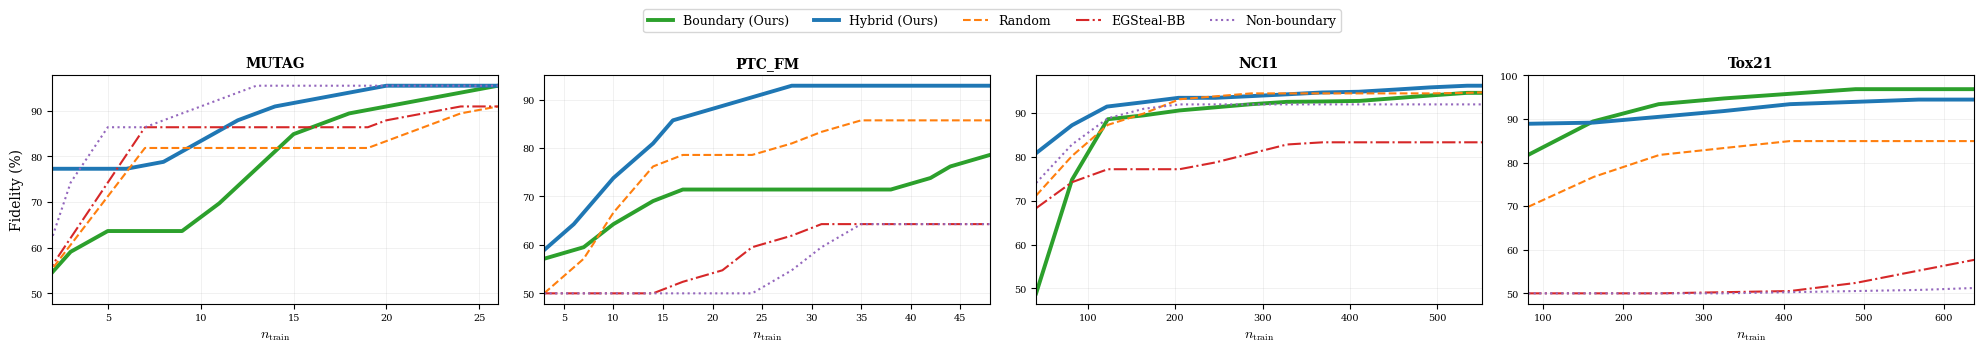

Saved fidelity_ntrain_GraphSAGE_PG.pdf


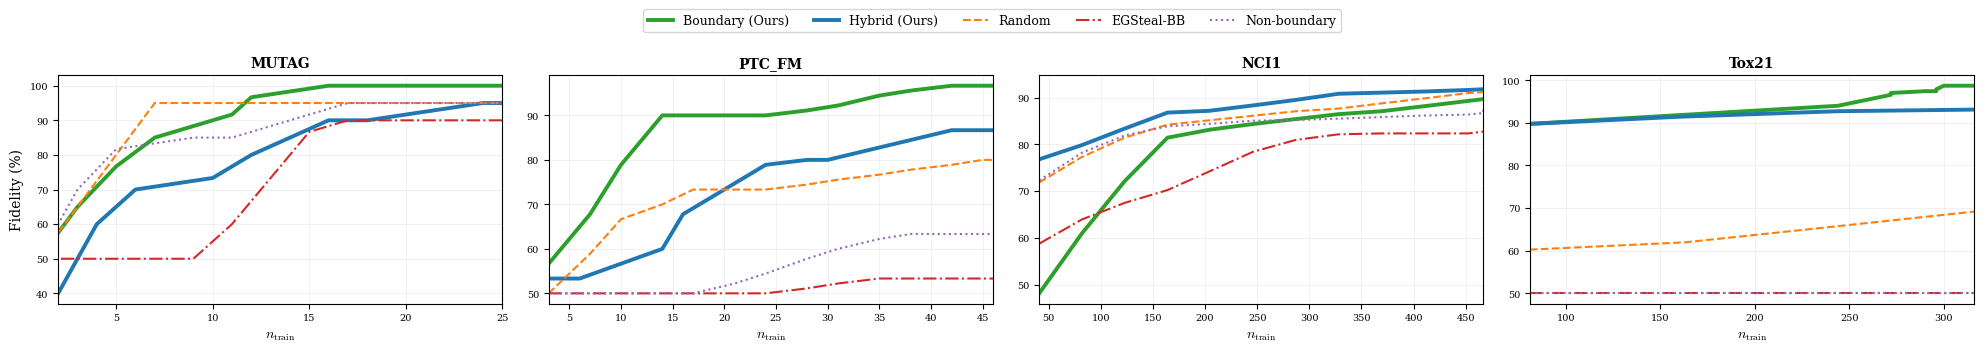

Saved fidelity_ntrain_combined.pdf


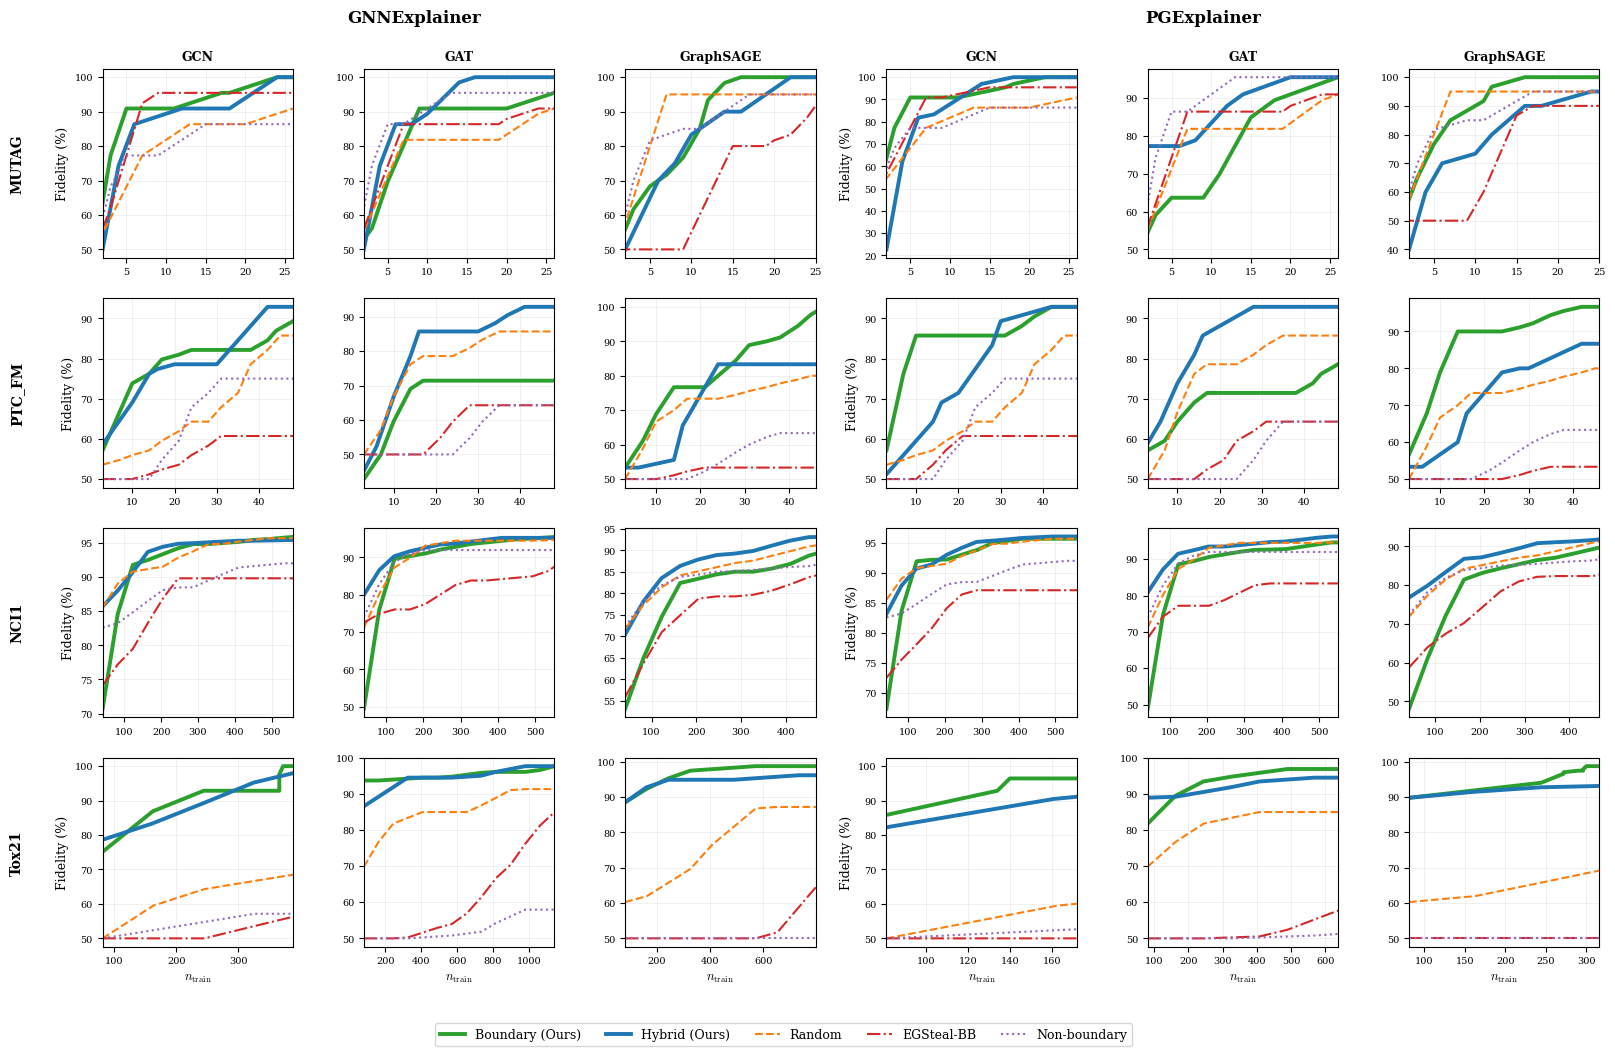

In [17]:
# Per-architecture figures
if SAVE_PDF:
    for exp_code in ['GNN', 'PG']:
        for arch in PLOT_ARCHITECTURES:
            make_single_figure(arch, exp_code=exp_code,
                               filename=f'fidelity_ntrain_{arch}_{exp_code}.pdf',
                               show=SHOW_INLINE, save=True)
# Combined 3-row figure
if SAVE_COMBINED:
    make_combined_figure(filename='fidelity_ntrain_combined.pdf',
                         show=SHOW_INLINE, save=True)